### You can run this notebook at Colab by clicking here:

<a target="_blank" href="https://colab.research.google.com/github/NMRLipids/databank-template/blob/main/scripts/template.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Initialize NMRlipids databank

In [1]:
import sys
import os
import re

# This installs FAIRMD Lipids in your python environment,
# you can use the same commands on your local machine if you run it locally.

!pip install fairmd-lipids

if not os.environ.get("FMDL_DATA_PATH", False):    
    if os.path.isdir('BilayerData'):
        print("Folder BilayerData already exist. Skip clonning..")
    else:
        !fmdl_initialize_data stable
    with open("databank_env.rc") as f:
        for s in f.readlines():
            m = re.match(r"^export\s+([A-Z_][A-Z0-9_]*)=(.+)$", s)
            if m:
                key, value = m.groups()
                print(f"Setting {key}={value}")
                os.environ[key] = value

# On local machine, you can set NMLDB_DATA_PATH to the path where you cloned the BilayerData repository.

Defaulting to user installation because normal site-packages is not writeable
Folder BilayerData already exist. Skip clonning..
Setting FMDL_DATA_PATH=/home/comcon1/repo/databank-template/scripts/BilayerData


In [2]:
import random

# These two lines include core Databank routines and Databank API
from fairmd.lipids.core import *
from fairmd.lipids.databankLibrary import *

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()

fairmd-lipids 1.3.2a0 by NMRlipids Open Collaboration - None
FAIRMD Lipids is initialized from the folder: /home/comcon1/repo/databank-template/scripts/BilayerData
---------------------------------------------------------------


/home/comcon1/.conda/envs/nmldb312dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Databank initialized from the folder: /home/comcon1/repo/databank-template/scripts/BilayerData/Simulations


# Select random simulation for example and show its content

In [3]:
 ### To exemplify the analysis of any simulation, we select randomly one simulation ID
randomID = None
while randomID is None:
    _rid = random.randint(1, len(systems))
    try:
        system = systems.loc(_rid)
        randomID = _rid
    except KeyError:
        pass
randomID = random.randint(1, len(systems))
#randomID=546
print('ID of the selected simulation: ', randomID)

# get system by ID
system = systems.loc(randomID)
print_README(system)

ID of the selected simulation:  419
AUTHORS_CONTACT:
  Javanainen, Matti
FF_DATE:
  None
SYSTEM:
  260DAPC_28CHOL_11520SOL_285K
TYPEOFSYSTEM:
  lipid bilayer
TEMPERATURE:
  285.0
PUBLICATION:
  None
NUMBER_OF_ATOMS:
  72512
EXPERIMENT:
  {'ORDERPARAMETER': {'CHOL': {}, 'DAPC': {}}, 'FORMFACTOR': {}}
FF_SOURCE:
  CHARMM-GUI v1.7
COMPOSITION:
  {'CHOL': {'NAME': 'CHL1', 'COUNT': [15, 13], 'MAPPING': 'mappingCHOLESTEROLcharmm.yaml'}, 'SOL': {'NAME': 'TIP3', 'COUNT': 11520, 'MAPPING': 'mappingTIP3PCHARMMgui.yaml'}, 'DAPC': {'NAME': 'DAPC', 'COUNT': [130, 130], 'MAPPING': 'mappingDAPCcharmm.yaml'}}
TIMELEFTOUT:
  0
CPT:
  [['DAPC_AA_CHOL10_CORE_285.cpt']]
TRJLENGTH:
  2000100.0
TRAJECTORY_SIZE:
  5412035880
SOFTWARE_VERSION:
  None
FF:
  CHARMM36
TOP:
  [['DAPC_AA_CHOL10_CORE.top']]
PREEQTIME:
  0
DOI:
  10.5281/zenodo.2653735
DATEOFRUNNING:
  06/10/2021
TPR:
  [['DAPC_AA_CHOL10_CORE_285.tpr']]
TRJ:
  [['DAPC_AA_CHOL10_CORE_285.xtc']]
LOG:
  [['DAPC_AA_CHOL10_CORE_285.log']]
SOFTWARE:
  gro

# Show analyzed properties stored in the NMRlipids databank for the selected system:

Membrane area per lipid: 68.38001200593742 

Membrane thickness: 3.964828971862793 

Relative equilibration time for each lipid in the simulation: 
{'DAPC': 0.0892055178634606}


Plot form factor and C-H bond order parameters from the simulation together with experimental data if available 

CHOL
DOI:  10.5281/zenodo.2653735
Force field quality not found


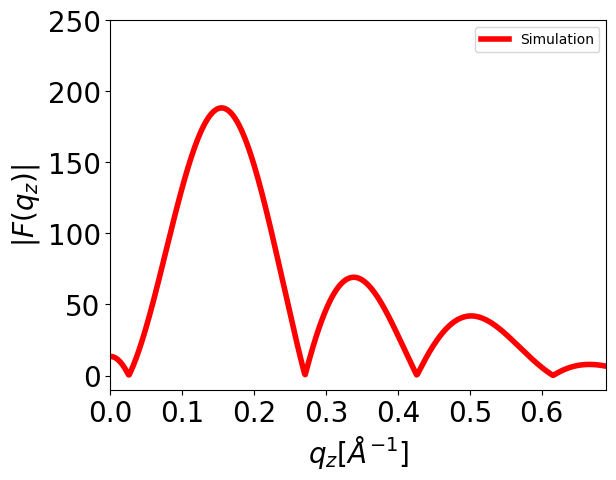

Form factor plotting failed


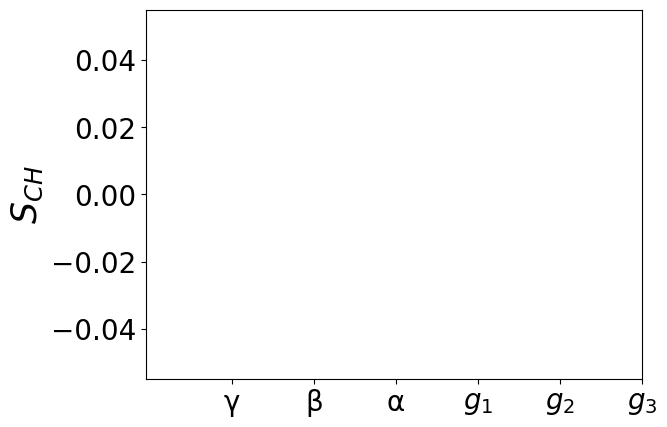

Plotting failed for  CHOL
min() iterable argument is empty
DAPC
DOI:  10.5281/zenodo.2653735
Force field quality not found


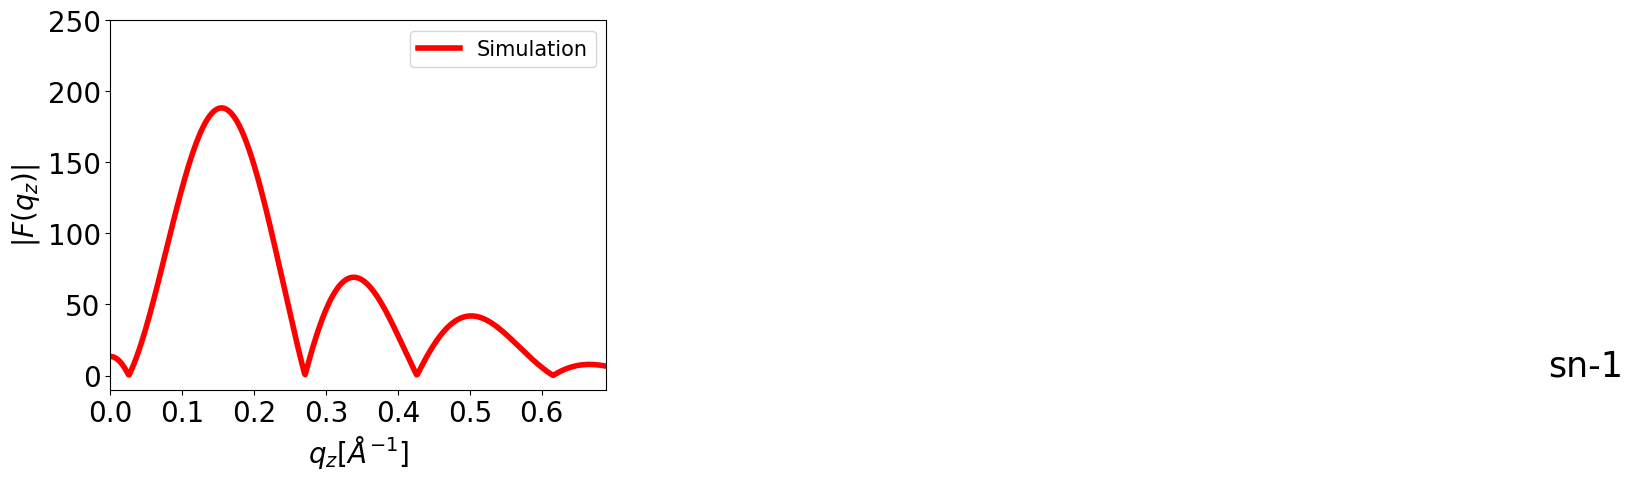

Form factor plotting failed


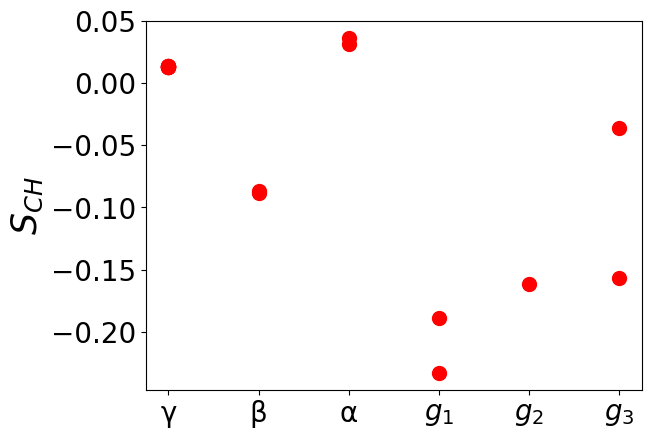

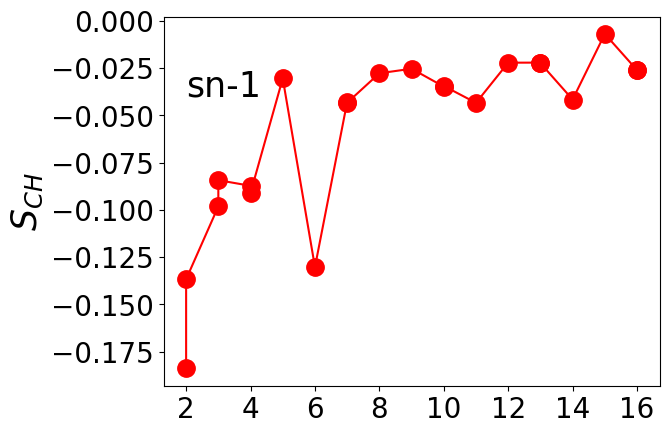

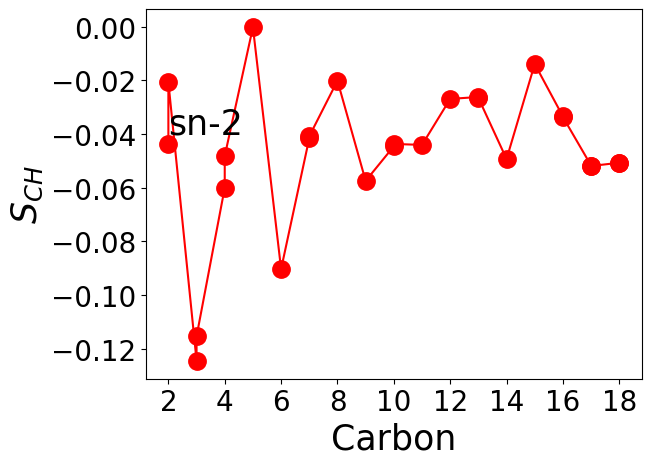

In [4]:
from fairmd.lipids.plottings import plotSimulation

## Membrane area per lipid, thickness, relative equilibration time, C-H bond order parameters
## and X-ray scattering form factors shown for the selected random simulation.
## We are doing all these things for a randomly picked system (loaded above).

APL = CalcAreaPerMolecule(system)
print('Membrane area per lipid:' , APL, '\n')

thickness = GetThickness(system)
print('Membrane thickness:' , thickness, '\n')

print('Relative equilibration time for each lipid in the simulation: ')
print(GetEquilibrationTimes(system))
print('\n')

print('Plot form factor and C-H bond order parameters from the simulation together with experimental data if available \n')
for lipid in system['COMPOSITION']:
    if lipid not in lipids_set:
        continue
    print(lipid)
    try:
        plotSimulation(system, lipid)
    except Exception as e:
        print('Plotting failed for ', lipid)
        print(e)


# Selects a random simulation with the trajectory size below 100Mb and calculates P-N vector angle with respect to membrane normal for all lipids for which P and N atoms are available in headgroup

In [5]:
systems.loc(756)

System(756): 30e/6ee/30e6eedb46c2d313b709697ae73f0671c5079dc6/7aac3f64c8467f18f5265bc5aa63ed6895c348cf/

In [6]:
## Print simulation specific

Patom_UNI = 'M_G3P2_M'   # universal name of phophate headgroup atom
Natom_UNI = 'M_G3N6_M'   # universal name of nitrogen headgroup atom


## Finding a random simulation with smaller than 100Mb trajectory for testing
for i in range(len(systems)):
    randomID = random.randint(1, len(systems))
    try:
        system = systems.loc(randomID)
    except KeyError:
        pass
    # This filters out larger than 100Mb trajectories for testing
    if system['TRAJECTORY_SIZE'] < 100000000:
        break

print('ID number of the selected simulation: ', randomID)

# Creates MDAnalysis universe from the simulation
# This will also download simulation files if not yet available locally
MDAuni = system2MDanalysisUniverse(system)

# Loops over molecules and calculates P-N vector angle if atoms are found
for molecule in system['COMPOSITION']:
    if molecule not in lipids_set:
        continue
    print('\n Analysing ' + molecule)
    Patom_SIM = simulation2universal_atomnames(system,molecule,Patom_UNI)
    #print(Patom_SIM)
    Natom_SIM = simulation2universal_atomnames(system,molecule,Natom_UNI)
    #print(Natom_SIM)
    if Patom_SIM == None or Natom_SIM == None:
        continue

    #print(molecule, Patom_SIM, Natom_SIM)
    resname = system['COMPOSITION'][molecule]['NAME']
    PNangles = read_trj_PN_angles(resname, Patom_SIM, Natom_SIM, MDAuni)

    print('PN vector angle for ' + molecule + ':' + str(PNangles[2]) + ' +/- ' + str(PNangles[3]) + '\n')

ID number of the selected simulation:  396


DOPC_313_small.xtc: 63.9MB [00:05, 11.3MB/s]                                                                                                                                                                        
DOPC_313_small.tpr: 632kB [00:01, 462kB/s]                                                                                                                                                                          
DOPC_313_small.gro: 1.22MB [00:00, 1.74MB/s]                                                                                                                                                                        



 Analysing DOPC
PN vector angle for DOPC:70.724545064321 +/- 0.13807770825009555

